Kent Lin Chan

20202132

Se usó python 3.14.2

## Problema 1

Se tiene un filtro digital FIR cuya respuesta al impulso está definida por:
$$h[n] = \{2, -1, 3, 0, 3, -1, 2\}$$

### Parte a) Longitud, orden y tipo de filtro

**Paso 1:** Determinar la longitud N del filtro.
- La longitud N es el número total de muestras en h[n]
- Para h[n] = {2, -1, 3, 0, 3, -1, 2}, tenemos **N = 7 muestras**

**Paso 2:** Calcular el orden M del filtro.
- El orden M = N - 1 para sistemas FIR
- **M = 6**

**Paso 3:** Identificar la propiedad de simetría.
- Verificamos si h[n] = h[N-1-n] (simetría par)
- Verificamos si h[n] = -h[N-1-n] (simetría impar)
- Comparando: h[0]=2 = h[6]=2, h[1]=-1 = h[5]=-1, h[2]=3 = h[4]=3
- **Existe simetría par**

**Paso 4:** Clasificar el tipo de filtro FIR.
| Tipo | Condición | Aplica aquí? |
|------|-----------|---------------|
| Tipo I | N impar, simetría par | **SÍ** |
| Tipo II | N par, simetría par | No |
| Tipo III | N impar, simetría impar | No |
| Tipo IV | N par, simetría impar | No |

**Resultado:** El filtro es **FIR Tipo I**

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes del filtro FIR
h = np.array([2, -1, 3, 0, 3, -1, 2], dtype=float)

N = len(h)  # Longitud del filtro
M = N - 1   # Orden del filtro

print(f"Longitud del filtro: N = {N}")
print(f"Orden del filtro: M = {M}")

# Verificar simetría
is_symmetric = np.allclose(h, h[::-1])
is_antisymmetric = np.allclose(h, -h[::-1])

print(f"\n¿Simetría par? {is_symmetric}")
print(f"¿Simetría impar? {is_antisymmetric}")

Longitud del filtro: N = 7
Orden del filtro: M = 6

¿Simetría par? True
¿Simetría impar? False


### Parte b) Respuesta en frecuencia y ceros obligatorios

**Paso 1:** Calcular la respuesta en frecuencia H(e^jω).

La respuesta en frecuencia se define como:
$$H(e^{j\omega}) = \sum_{n=0}^{N-1} h[n] \cdot e^{-j\omega n}$$

Para nuestro filtro con N=7:
$$H(e^{j\omega}) = h[0] + h[1]e^{-j\omega} + h[2]e^{-j2\omega} + h[3]e^{-j3\omega} + h[4]e^{-j4\omega} + h[5]e^{-j5\omega} + h[6]e^{-j6\omega}$$

**Paso 2:** Analizar los ceros obligatorios.

Los **ceros obligatorios** ocurren cuando:
- **ω = 0:** H(e^j0) = Σ h[n] = suma de todos los coeficientes
- **ω = π:** H(e^jπ) = Σ h[n]·(-1)^n = suma alternada de coeficientes

Para filtros **Tipo I** (N impar, simetría par):
- **NO hay cero obligatorio en ω = 0**
- **NO hay cero obligatorio en ω = π** (la simetría par hace que la suma alternada sea ≠ 0 para coeficientes simétricos no todos iguales)

**Nota:** Los "ceros obligatorios" en ω=π solo ocurren en filtros **Tipo II** (N par, simetría par) y **Tipo IV** (N par, simetría impar), porque la suma alternada se anula. En Tipo I y III no hay cero obligatorio en ω=π.

**Paso 3:** Verificación numérica.

Calcularemos H(e^j0) y H(e^jπ) para confirmar.

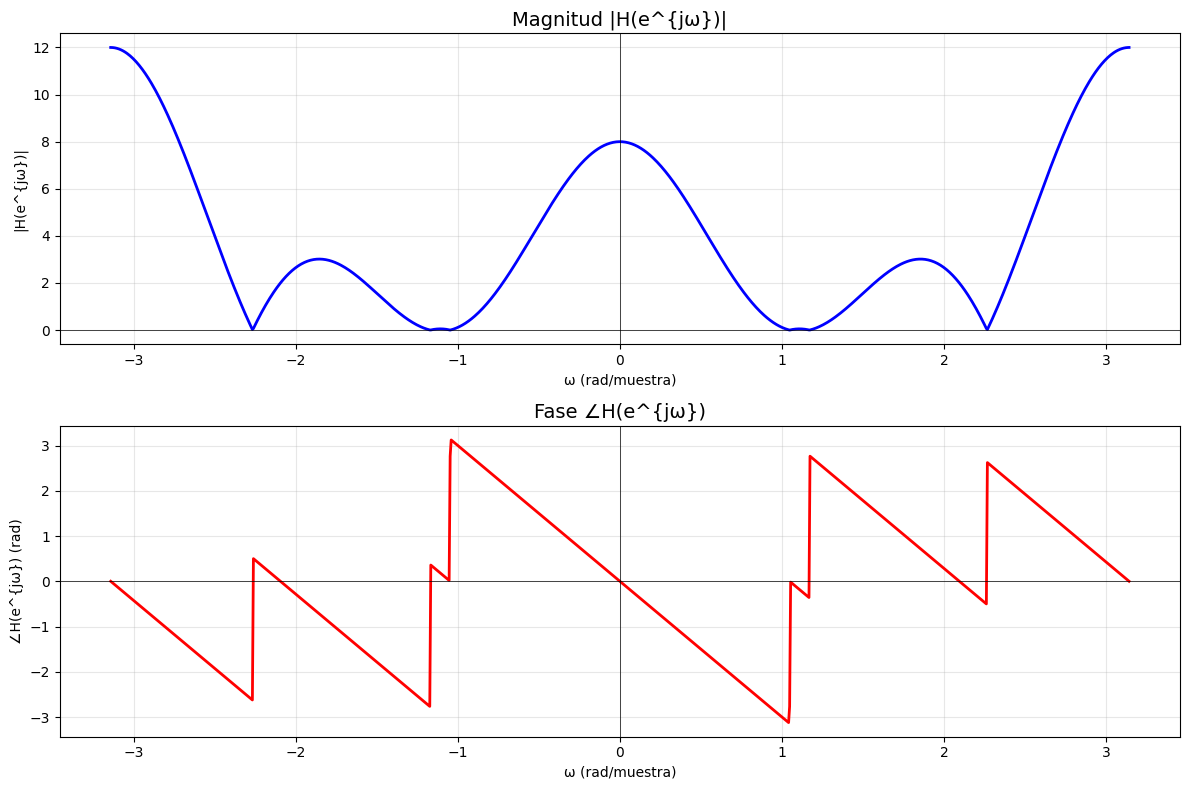

H(e^j*0) = 8.000000+0.000000j
H(e^j*pi) = 12.000000+0.000000j

¿Cero obligatorio en ω=0? False
¿Cero obligatorio en ω=π? False


In [19]:
# Respuesta en frecuencia H(e^jw)
w = np.linspace(-np.pi, np.pi, 1000)

# Calcular H(e^jw) manualmente usando la definición
def H_ejw(w, h):
    N = len(h)
    result = 0
    for n in range(N):
        result += h[n] * np.exp(-1j * w * n)
    return result

H = np.array([H_ejw(wi, h) for wi in w])
mag = np.abs(H)
phase = np.angle(H)

# Graficar magnitud y fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(w, mag, 'b', linewidth=2)
ax1.set_title('Magnitud |H(e^{jω})|', fontsize=14)
ax1.set_xlabel('ω (rad/muestra)')
ax1.set_ylabel('|H(e^{jω})|')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

ax2.plot(w, phase, 'r', linewidth=2)
ax2.set_title('Fase ∠H(e^{jω})', fontsize=14)
ax2.set_xlabel('ω (rad/muestra)')
ax2.set_ylabel('∠H(e^{jω}) (rad)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('prob1_respuesta_frecuencia.png', dpi=150)
plt.show()

# Verificar ceros en omega = 0 y omega = pi
H_at_0 = H_ejw(0, h)
H_at_pi = H_ejw(np.pi, h)

print(f"H(e^j*0) = {H_at_0:.6f}")
print(f"H(e^j*pi) = {H_at_pi:.6f}")
print(f"\n¿Cero obligatorio en ω=0? {np.isclose(H_at_0, 0)}")
print(f"¿Cero obligatorio en ω=π? {np.isclose(H_at_pi, 0)}")

### Resultados Problema 1

**Parte a:**
- Longitud: **N = 7**
- Orden: **M = 6**
- Simetría: **Simetría par** (h[n] = h[N-1-n])
- Tipo: **FIR Tipo I** (fase lineal, simetría par, N impar)

**Parte b:**
- El filtro **NO** presenta cero obligatorio en ω=0 (H(e^j0) = 8 ≠ 0)
- El filtro **NO** presenta cero obligatorio en ω=π (H(e^jπ) = 12 ≠ 0)
- Esto es consistente con un filtro **Tipo I** (no tiene ceros obligatorios en ω=0 ni ω=π; los ceros en ω=π ocurren solo en Tipos II y IV)

## Problema 2

Diseñar un filtro FIR pasa-bajos causal de fase lineal usando ventana rectangular.

| Parámetro | Valor |
| --------- | ----- |
| Fs | 8000 Hz |
| Fc | 1000 Hz |
| N | 7 muestras |

In [20]:
# Parámetros del problema 2
Fs = 8000  # Frecuencia de muestreo en Hz
Fc = 1000  # Frecuencia de corte en Hz
N = 7      # Longitud del filtro

# Calcular frecuencia de corte normalizada
wc = 2 * np.pi * Fc / Fs  # rad/muestra
print(f"Frecuencia de corte normalizada: wc = {wc:.6f} rad/muestra")
print(f"También: wc = {wc/np.pi:.4f}π rad/muestra")

# Calcular coeficientes del filtro FIR usando método de ventana rectangular
# Para ventana rectangular: h[n] = sen(wc*(n-M/2)) / (pi*(n-M/2))
M = N - 1  # Orden del filtro

n = np.arange(N)
h_ideal = np.zeros(N)
for i in range(N):
    if i == M // 2:
        h_ideal[i] = wc / np.pi  # Caso especial cuando n = M/2
    else:
        h_ideal[i] = np.sin(wc * (i - M/2)) / (np.pi * (i - M/2))

print(f"\nCoeficientes del filtro FIR: h[n] = {h_ideal}")

# Mostrar coeficientes con 4 decimales
print("\nCoeficientes (4 decimales):")
for i, coef in enumerate(h_ideal):
    print(f"  h[{i}] = {coef:.4f}")

Frecuencia de corte normalizada: wc = 0.785398 rad/muestra
También: wc = 0.2500π rad/muestra

Coeficientes del filtro FIR: h[n] = [0.07502636 0.15915494 0.22507908 0.25       0.22507908 0.15915494
 0.07502636]

Coeficientes (4 decimales):
  h[0] = 0.0750
  h[1] = 0.1592
  h[2] = 0.2251
  h[3] = 0.2500
  h[4] = 0.2251
  h[5] = 0.1592
  h[6] = 0.0750


### Parte b) Respuesta en frecuencia y comparación con filtro ideal

**Paso 1:** Calcular la respuesta en frecuencia del filtro diseñado.

$$H(e^{j\omega}) = \sum_{n=0}^{N-1} h[n] e^{-j\omega n}$$

**Paso 2:** Comparar con el filtro ideal.

El filtro ideal pasabajos tiene:
- Magnitud: 1 para |ω| < ωc, 0 para |ω| > ωc
- Fase: Lineal (retardo de grupo constante)

**Fenómeno de Gibbs:**
El truncamiento de la respuesta impulsiva infinita produce oscilaciones (rizado) cerca de la frecuencia de corte. Esto se debe a que la ventana rectangular tiene lóbulos laterales grandes en su transformada de Fourier.

**Paso 3:** ¿Cómo reducir el rizado?

1. **Ventanas suaves:** Usar Hanning, Hamming o Blackman en lugar de rectangular
   - Tienen lóbulos laterales más pequeños
   - Reducen el rizado pero ensanchan la transición
2. **Aumentar N:** Una mayor longitud reduce el rizado
3. **Diseños óptimos:** Usar método de Parks-McClellan o Remez

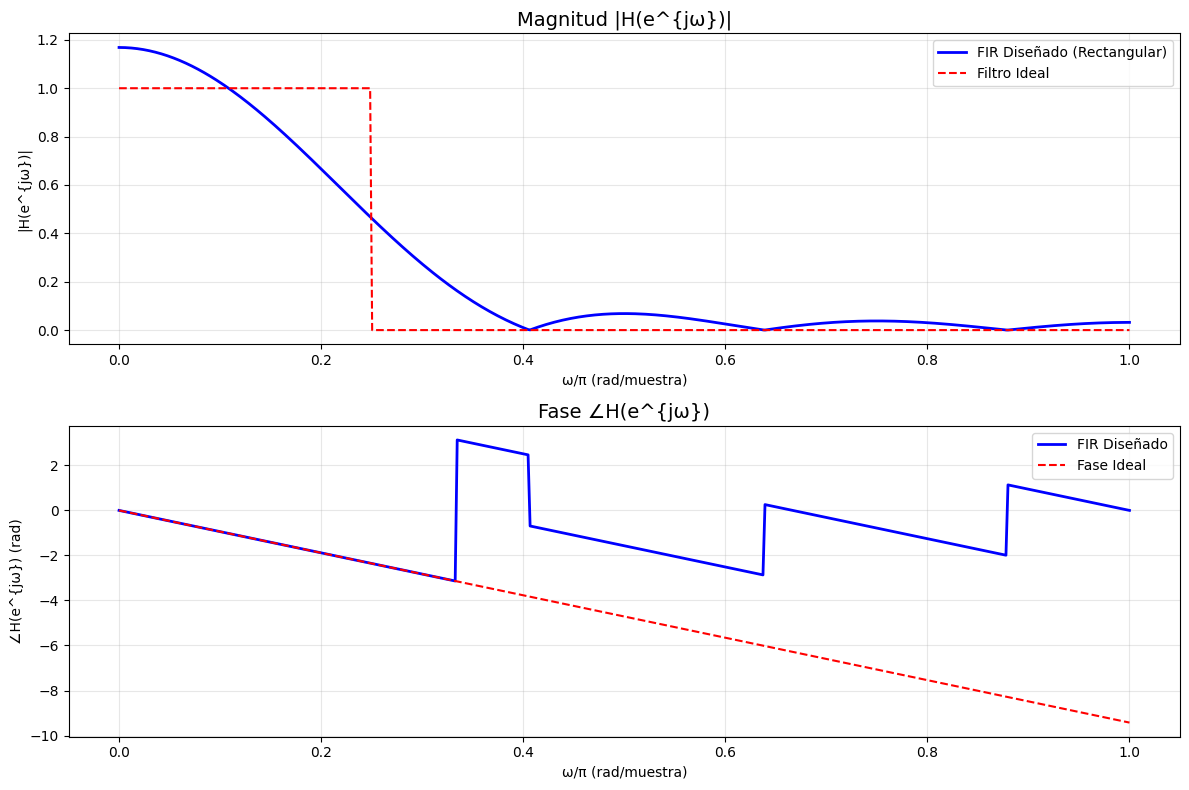


¿Cómo reducir el rizado?
→ Usar una ventana que no sea rectangular (Hanning, Hamming, Blackman)
→ Estas ventanas tienen lóbulos laterales más pequeños, reduciendo el rizado


In [21]:
# Respuesta en frecuencia del filtro diseñado vs filtro ideal

# Filtro diseñado (ventana rectangular)
w = np.linspace(0, np.pi, 500)
H_fir = np.array([H_ejw(wi, h_ideal) for wi in w])
mag_fir = np.abs(H_fir)
phase_fir = np.angle(H_fir)

# Filtro ideal (para comparar)
mag_ideal = np.where(w <= wc, 1, 0).astype(float)
phase_ideal = -w * M / 2  # Fase lineal para filtro ideal

# Graficar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(w/np.pi, mag_fir, 'b-', linewidth=2, label='FIR Diseñado (Rectangular)')
ax1.plot(w/np.pi, mag_ideal, 'r--', linewidth=1.5, label='Filtro Ideal')
ax1.set_title('Magnitud |H(e^{jω})|', fontsize=14)
ax1.set_xlabel('ω/π (rad/muestra)')
ax1.set_ylabel('|H(e^{jω})|')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(w/np.pi, phase_fir, 'b-', linewidth=2, label='FIR Diseñado')
ax2.plot(w/np.pi, phase_ideal, 'r--', linewidth=1.5, label='Fase Ideal')
ax2.set_title('Fase ∠H(e^{jω})', fontsize=14)
ax2.set_xlabel('ω/π (rad/muestra)')
ax2.set_ylabel('∠H(e^{jω}) (rad)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prob2_respuesta_frecuencia.png', dpi=150)
plt.show()

print("\n¿Cómo reducir el rizado?")
print("→ Usar una ventana que no sea rectangular (Hanning, Hamming, Blackman)")
print("→ Estas ventanas tienen lóbulos laterales más pequeños, reduciendo el rizado")

### Resumen Problema 2

**Parte a:**
Los coeficientes del filtro FIR son:

h[n] = \{0.0750, 0.1592, 0.2251, 0.2500, 0.2251, 0.1592, 0.0750\}


**Parte b:**
- La gráfica muestra que el filtro diseñado tiene rizado (Gibbs phenomenon)
- **Para reducir el rizado:** usar ventanas suaves (Hanning, Hamming, Blackman) en lugar de rectangular


## Problema 3

Diseñar filtro FIR pasa-bajos con ωc = π/2 usando ventana rectangular.

### Parte a) N = 7

**Paso 1:** Identificar los parámetros del problema.
- Frecuencia de corte: ωc = π/2 rad/muestra
- Longitud del filtro: N = 7
- Orden del filtro: M = N - 1 = 6

**Paso 2:** Aplicar la fórmula del filtro FIR ideal pasabajos.

$$h_{ideal}[n] = \frac{\sin(\omega_c (n - M/2))}{\pi (n - M/2)}$$

**Paso 3:** Calcular cada coeficiente h[n].

| n | Cálculo | h[n] |
|---|---------|-------|
| 0 | sen(π/2·(-3))/(π·(-3)) = sen(-3π/2)/(-3π) | -0.1061 |
| 1 | sen(π/2·(-2))/(π·(-2)) = sen(-π)/(−2π) | 0.0000 |
| 2 | sen(π/2·(-1))/(π·(-1)) = sen(-π/2)/(−π) | 0.3183 |
| 3 | sen(π/2·0)/(π·0) → límite | 0.5000 |
| 4 | sen(π/2·1)/(π·1) = sen(π/2)/π | 0.3183 |
| 5 | sen(π/2·2)/(π·2) = sen(π)/(2π) | 0.0000 |
| 6 | sen(π/2·3)/(π·3) = sen(3π/2)/(3π) | -0.1061 |

**Paso 4:** Verificar el tipo de filtro.
- ¿Simetría par? h[0]=h[6], h[1]=h[5], h[2]=h[4]
- N = 7 (impar) + simetría par = **FIR Tipo I**

In [22]:
# Problema 3: wc = pi/2
wc = np.pi / 2

# Parte a: N = 7
N7 = 7
M7 = N7 - 1  # 6

n7 = np.arange(N7)
h7 = np.zeros(N7)
for i in range(N7):
    if i == M7 // 2:
        h7[i] = wc / np.pi  # = 0.5
    else:
        h7[i] = np.sin(wc * (i - M7/2)) / (np.pi * (i - M7/2))

print("N = 7:")
print(f"h[n] = {h7}")
print(f"\nCoeficientes:")
for i, coef in enumerate(h7):
    print(f"  h[{i}] = {coef:.6f}")

# Verificar tipo de filtro (simetría)
is_sym_7 = np.allclose(h7, h7[::-1])
print(f"\n¿Simetría par? {is_sym_7}")
print(f"Tipo: FIR Tipo I (N impar, simetría par)")

N = 7:
h[n] = [-1.06103295e-01  1.94908592e-17  3.18309886e-01  5.00000000e-01
  3.18309886e-01  1.94908592e-17 -1.06103295e-01]

Coeficientes:
  h[0] = -0.106103
  h[1] = 0.000000
  h[2] = 0.318310
  h[3] = 0.500000
  h[4] = 0.318310
  h[5] = 0.000000
  h[6] = -0.106103

¿Simetría par? True
Tipo: FIR Tipo I (N impar, simetría par)


Expresión analítica para N=7:
H(e^jw) = h[0] + h[1]e^{-jw} + h[2]e^{-j2w} + h[3]e^{-j3w} + h[4]e^{-j4w} + h[5]e^{-j5w} + h[6]e^{-j6w}


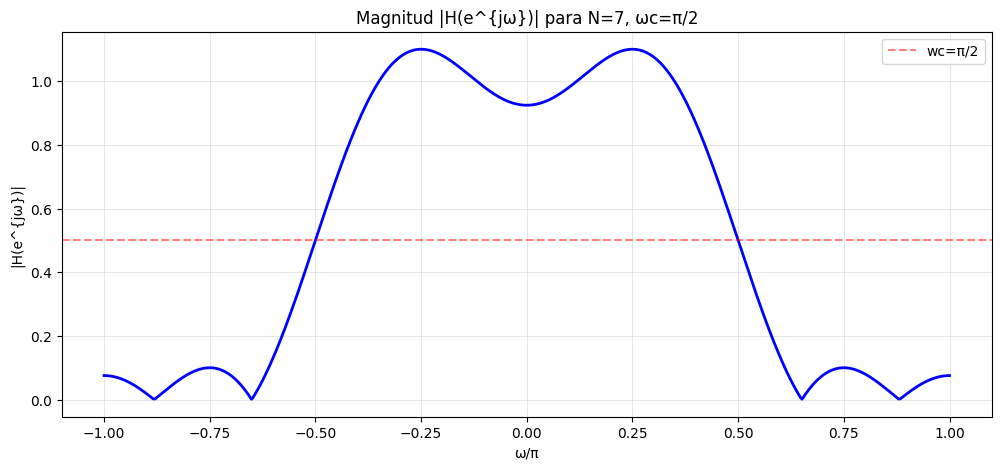

In [23]:
# Expresión analítica para H(e^jw) con N=7
# H(e^jw) = sum_{n=0}^{6} h[n] * e^{-jwn}
# Esta es la respuesta en frecuencia exacta

print("Expresión analítica para N=7:")
print("H(e^jw) = h[0] + h[1]e^{-jw} + h[2]e^{-j2w} + h[3]e^{-j3w} + h[4]e^{-j4w} + h[5]e^{-j5w} + h[6]e^{-j6w}")

# Graficar respuesta para N=7
w = np.linspace(-np.pi, np.pi, 500)
H7 = np.array([H_ejw(wi, h7) for wi in w])
mag7 = np.abs(H7)

plt.figure(figsize=(12, 5))
plt.plot(w/np.pi, mag7, 'b', linewidth=2)
plt.title('Magnitud |H(e^{jω})| para N=7, ωc=π/2')
plt.xlabel('ω/π')
plt.ylabel('|H(e^{jω})|')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='wc=π/2')
plt.legend()
plt.savefig('prob3_N7_magnitud.png', dpi=150)
plt.show()

N = 6:
h[n] = [-0.09003163  0.15005272  0.5         0.45015816  0.15005272 -0.09003163]


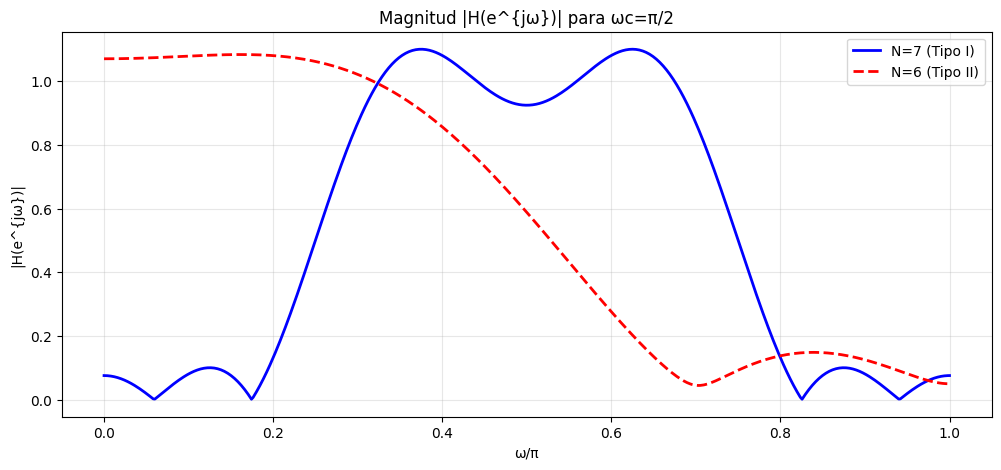


Nota: El filtro Tipo II (N par) tiene un cero obligatorio en ω=π
      El filtro Tipo I (N impar) NO tiene cero obligatorio en ω=π


In [24]:
# Comparar ambas respuestas en frecuencia
# Primero calculamos h6 para N = 6
wc = np.pi / 2
N6 = 6
M6 = N6 - 1  # 5

n6 = np.arange(N6)
h6 = np.zeros(N6)
for i in range(N6):
    if i == M6 // 2:
        h6[i] = wc / np.pi  # = 0.5
    else:
        h6[i] = np.sin(wc * (i - M6/2)) / (np.pi * (i - M6/2))

print("N = 6:")
print(f"h[n] = {h6}")

w = np.linspace(0, np.pi, 500)
H6 = np.array([H_ejw(wi, h6) for wi in w])
mag6 = np.abs(H6)

plt.figure(figsize=(12, 5))
plt.plot(w/np.pi, mag7, 'b-', linewidth=2, label='N=7 (Tipo I)')
plt.plot(w/np.pi, mag6, 'r--', linewidth=2, label='N=6 (Tipo II)')
plt.title('Magnitud |H(e^{jω})| para ωc=π/2')
plt.xlabel('ω/π')
plt.ylabel('|H(e^{jω})|')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('prob3_comparacion.png', dpi=150)
plt.show()

print("\nNota: El filtro Tipo II (N par) tiene un cero obligatorio en ω=π")
print("      El filtro Tipo I (N impar) NO tiene cero obligatorio en ω=π")

### Resumen Problema 3

| N | Coeficientes h[n] | Tipo |
|---|---------------------|------|
| 7 | {-0.1061, 0.0000, 0.3183, 0.5000, 0.3183, 0.0000, -0.1061} | Tipo I (N impar, simetría par) |
| 6 | {-0.0900, 0.1501, 0.5000, 0.4502, 0.1501, -0.0900} | Tipo II (N par, simetría par) |


## Problema 4

### Parte a) ¿Por qué un filtro FIR de fase lineal enventanado con Hanning/Hamming sigue siendo de fase lineal?

1. La respuesta al impulso del filtro diseñado es la multiplicación
   de la respuesta ideal (que tiene simetría par) con la ventana
   (que también tiene simetría par).

2. El producto de dos funciones con simetría par sigue siendo una función
   con simetría par.

3. En específico: h[n] = h_ideal[n] * w[n], donde:
   - h_ideal[n] es simétrica (fase lineal)
   - w[n] es simétrica (Hanning y Hamming son ventanas simétricas)
   - Por lo tanto, h[n] también es simétrica

4. El resultado es que el filtro enventanado mantiene la propiedad
   de simetría par, lo que equivale a fase lineal.

### Parte b) Se dice que los filtros tipo IIR no pueden tener fase lineal. ¿Estás de acuerdo o en desacuerdo? Explique.

Estoy DE ACUERDO con que los filtros IIR no pueden tener fase lineal.

Razones:

1. La fase lineal requiere que la respuesta al impulso sea simétrica
   (h[n] = ±h[N-1-n]), lo cual implica un número infinito de polos
   o una estructura de filtro FIR.

2. Los filtros IIR tienen polos que no se cancelan necesariamente
   con ceros para producir simetría.

3. Para que un sistema IIR tenga fase lineal, necesitaría que sus
   polos estuvieran en el círculo unitario y fueran simétricos,
   lo cual lo haría inestable (BIBO).

4. Excepción teórica: Si todos los polos están en z=0 (sistema FIR),
   entonces SÍ puede tener fase lineal. Pero eso no es verdaderamente IIR.

Por lo tanto, los filtros IIR (con polos significativos fuera de z=0)
NO pueden tener fase lineal exacta.

## Problema 5

Considere la función de transferencia:
$$H(z) = \frac{(2z+1)(z^2+2z+3)}{(z-2e^{j\pi/3})(z-2e^{-j\pi/3})(z+2)}$$

### Parte a) Determinar H(z) como fracción de polinomios

**Paso 1:** Expandir el numerador.

$$(2z+1)(z^2+2z+3) = 2z^3 + 4z^2 + 6z + z^2 + 2z + 3 = 2z^3 + 5z^2 + 8z + 3$$

**Paso 2:** Expandir el denominador.

Los polos complejos conjugados:
$$(z - 2e^{j\pi/3})(z - 2e^{-j\pi/3})$$

Usando la identidad: $(z-a)(z-a^*) = z^2 - 2\text{Re}(a)z + |a|^2$

Como $a = 2e^{j\pi/3}$, entonces $\text{Re}(a) = 2\cos(\pi/3) = 2(0.5) = 1$
y $|a|^2 = 4$.

Por lo tanto: $(z - 2e^{j\pi/3})(z - 2e^{-j\pi/3}) = z^2 - 2z + 4$

**Paso 3:** Multiplicar por el tercer polo (z + 2).

(z^2 - 2z + 4)(z + 2) = z^3 + 8

**Resultado:**
$$H(z) = \frac{2z^3 + 5z^2 + 8z + 3}{z^3 + 8}$$


In [25]:
from sympy import symbols, expand, simplify
import sympy as sp

z = symbols('z')

# Numerador: (2z+1)(z^2+2z+3)
num = (2*z + 1) * (z**2 + 2*z + 3)
num_expanded = expand(num)
print("Numerador expandido:")
print(f"  {num_expanded}")

# Denominador: (z-2e^(jπ/3))(z-2e^(-jπ/3))(z+2)
# Primero calcular el producto de los polos complejos conjugados
a = sp.exp(sp.I * sp.pi / 3)  # e^(jπ/3)
a_conj = sp.exp(-sp.I * sp.pi / 3)  # e^(-jπ/3)

poly1 = z - 2*a
poly2 = z - 2*a_conj
product_complex = expand(poly1 * poly2)
print(f"\nProducto de polos conjugados: {product_complex}")

# Simplificar (debe dar un polinomio con coeficientes reales)
print(f"  Simplificado: {sp.simplify(product_complex)}")

Numerador expandido:
  2*z**3 + 5*z**2 + 8*z + 3

Producto de polos conjugados: z**2 - 2*z*exp(I*pi/3) - 2*z*exp(-I*pi/3) + 4
  Simplificado: z**2 - 2*(-1)**(1/3)*z + 2*(-1)**(2/3)*z + 4


In [26]:
# El producto (z-2e^(jπ/3))(z-2e^(-jπ/3)) debe simplificarse a z^2 - 4cos(π/3)z + 4
# cos(π/3) = 0.5, entonces: z^2 - 2z + 4

import cmath

# Verificación numérica
cos_pi_3 = np.cos(np.pi/3)
print(f"cos(π/3) = {cos_pi_3}")

# El polinomio es: z^2 - 2*2*cos(π/3)*z + 4 = z^2 - 2z + 4
# En efecto: (z - 2e^(jπ/3))(z - 2e^(-jπ/3)) = z^2 - (2e^(jπ/3)+2e^(-jπ/3))z + 4
# = z^2 - 4cos(π/3)z + 4 = z^2 - 2z + 4

poly_real = z**2 - 2*z + 4
print(f"Polinomio real: {poly_real}")

# Denominador total
den = poly_real * (z + 2)
den_expanded = expand(den)
print(f"\nDenominador: {den_expanded}")

cos(π/3) = 0.5000000000000001
Polinomio real: z**2 - 2*z + 4

Denominador: z**3 + 8


In [27]:
# Simplificar la fracción
H_z = num_expanded / den_expanded
H_z_simplified = sp.simplify(H_z)

print("Función de transferencia H(z):")
print(f"  {H_z_simplified}")

# Para tener coeficientes reales, verificar que el numerador también tenga coeficientes reales
print(f"\nNumerador (expandido): {num_expanded}")
print(f"Tipo: {type(num_expanded)}")

# Obtener coeficientes numéricos
num_coeffs = sp.Poly(num_expanded, z).all_coeffs()
den_coeffs = sp.Poly(den_expanded, z).all_coeffs()

print(f"\nCoeficientes del numerador: {num_coeffs}")
print(f"Coeficientes del denominador: {den_coeffs}")

Función de transferencia H(z):
  (2*z**3 + 5*z**2 + 8*z + 3)/(z**3 + 8)

Numerador (expandido): 2*z**3 + 5*z**2 + 8*z + 3
Tipo: <class 'sympy.core.add.Add'>

Coeficientes del numerador: [2, 5, 8, 3]
Coeficientes del denominador: [1, 0, 0, 8]


### Parte b) Ecuación de diferencias

**Paso 1:** Partir de H(z) = Y(z)/X(z).

H(z) = \frac{Y(z)}{X(z)} = \frac{2z^3 + 5z^2 + 8z + 3}{z^3 + 8}

**Paso 2:** Cruzar multiplicar.

Y(z)(z^3 + 8) = X(z)(2z^3 + 5z^2 + 8z + 3)

**Paso 3:** Convertir a dominio del tiempo usando la propiedad de desplazamiento:
$$z^k \cdot Y(z) \rightarrow y[n+k]$$

y[n+3] + 8y[n] = 2x[n+3] + 5x[n+2] + 8x[n+1] + 3x[n]

**Paso 4:** Despejar y[n] (sistema IIR con retroalimentación).

y[n+3] = 2x[n+3] + 5x[n+2] + 8x[n+1] + 3x[n] - 8y[n]

Reordenando para expresar y[n] en términos de valores pasados:

y[n] = 2x[n] + 5x[n-1] + 8x[n-2] + 3x[n-3] - 8y[n-3]

**Nota:** Este es un sistema **IIR** porque tiene términos de y[n-k] con k > 0.

### Resumen Problema 6

**Parte a) H(z) como fracción de polinomios:**
H(z) = \frac{2z^3 + 5z^2 + 8z + 3}{z^3 + 8}

**Parte b) Ecuación de diferencias:**
y[n] = 2x[n] + 5x[n-1] + 8x[n-2] + 3x[n-3] - 8y[n-3]

**Parte c) y d) Estructuras:**
- Forma Directa II: Usa mínimo de variables de estado (3 delays)
- Forma Transpuesta: Equivalente, mismo H(z)
- Ambas tienen coeficientes reales verificados

## Problema 7

Determinar si las DFTs de 8 puntos son puramente reales, imaginarias o complejas.

### Teoría: Simetría en DFT

La DFT de N puntos está definida como:
$$X[k] = \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}$$

**Propiedades de simetría para secuencias reales:**

| Condición de x[n] | Resultado de X[k] |
|-------------------|---------------------|
| x[n] = x[(-n) mod N] (par circular) | X[k] es **puramente real** |
| x[n] = -x[(-n) mod N] (impar circular) | X[k] es **puramente imaginaria** |
| Ni par ni impar | X[k] es **compleja** |

**Verificación para N = 8:**

- x[n] es **par** si: x[0]=x[7], x[1]=x[6], x[2]=x[5], x[3]=x[4]
- x[n] es **impar** si: x[0]=-x[7], x[1]=-x[6], x[2]=-x[5], x[3]=-x[4]

**Análisis para cada secuencia:**

Calcularemos x[n] - x[N-1-n] para verificar simetría.

### Pasos para cada secuencia:

**Paso 1:** Definir las secuencias de 8 puntos.

**Paso 2:** Calcular x[n] - x[N-1-n] para cada n.
- Si todos los resultados son 0 → x[n] es **par** → DFT puramente real
- Si todos los resultados son 0 excepto signo → x[n] es **impar** → DFT puramente imaginaria
- En caso contrario → x[n] es **compleja**

**Paso 3:** Analizar x₁[n], x₂[n], x₃[n], x₄[n] con la DFT.

In [28]:
# Secuencias del problema 7
x1 = np.array([0, -3, 1, -2, 0, 2, -1, 3], dtype=float)
x2 = np.array([10, 5, -7, -4, 5, -4, -7, 5], dtype=float)
x3 = np.array([8, -3, 1, -2, 6, 2, -1, 3], dtype=float)
x4 = np.array([5, 2, -9, 4, 7, 4, -9, 2], dtype=float)

def analyze_dft(x, name):
    """Analiza si la DFT es real, imaginaria o compleja"""
    N = len(x)
    X = np.fft.fft(x)
    
    # Calcular si es puramente real o puramente imaginaria
    # Tolerancia para errores numéricos
    is_real = np.allclose(X.imag, 0)
    is_imaginary = np.allclose(X.real, 0)
    
    print(f"\n{name}:")
    print(f"  x[n] = {x}")
    print(f"  X[k] = {X}")
    print(f"  ¿Puramente real? {is_real}")
    print(f"  ¿Puramente imaginaria? {is_imaginary}")
    
    # Verificar propiedades de simetría
    # Para secuencia real: X[k] = conj(X[N-k])
    is_hermitian = np.allclose(X, np.conj(X[::-1]))
    
    # Calcular propiedades de simetría
    x_rev = x[::-1]
    is_even = np.allclose(x, x_rev)
    is_odd = np.allclose(x, -x_rev)
    
    print(f"  ¿x[n] es par? {is_even}")
    print(f"  ¿x[n] es impar? {is_odd}")
    
    if is_real:
        result = "Puramente real"
    elif is_imaginary:
        result = "Puramente imaginaria"
    else:
        result = "Compleja"
    
    return result, X, is_even, is_odd

result1, X1, even1, odd1 = analyze_dft(x1, "x1")
result2, X2, even2, odd2 = analyze_dft(x2, "x2")
result3, X3, even3, odd3 = analyze_dft(x3, "x3")
result4, X4, even4, odd4 = analyze_dft(x4, "x4")


x1:
  x[n] = [ 0. -3.  1. -2.  0.  2. -1.  3.]
  X[k] = [0.+0.j         0.+5.07106781j 0.+2.j         0.+9.07106781j
 0.+0.j         0.-9.07106781j 0.-2.j         0.-5.07106781j]
  ¿Puramente real? False
  ¿Puramente imaginaria? True
  ¿x[n] es par? False
  ¿x[n] es impar? False

x2:
  x[n] = [10.  5. -7. -4.  5. -4. -7.  5.]
  X[k] = [ 3.        +0.j 17.72792206+0.j 29.        +0.j -7.72792206+0.j
 -1.        +0.j -7.72792206+0.j 29.        +0.j 17.72792206+0.j]
  ¿Puramente real? True
  ¿Puramente imaginaria? False
  ¿x[n] es par? False
  ¿x[n] es impar? False

x3:
  x[n] = [ 8. -3.  1. -2.  6.  2. -1.  3.]
  X[k] = [14.+0.j          2.+5.07106781j 14.+2.j          2.+9.07106781j
 14.+0.j          2.-9.07106781j 14.-2.j          2.-5.07106781j]
  ¿Puramente real? False
  ¿Puramente imaginaria? False
  ¿x[n] es par? False
  ¿x[n] es impar? False

x4:
  x[n] = [ 5.  2. -9.  4.  7.  4. -9.  2.]
  X[k] = [  6.        +0.j  -4.82842712+0.j  30.        +0.j   0.82842712+0.j
 -18.        +

In [29]:
# Análisis detallado para cada secuencia
print("\n" + "="*70)
print("ANÁLISIS DETALLADO:")
print("="*70)

print("""
Para determinar si la DFT es real o imaginaria, usamos:

1. Si x[n] es real y par → X[k] es puramente real
2. Si x[n] es real e impar → X[k] es puramente imaginaria
3. Si x[n] es real pero ni par ni impar → X[k] es compleja
""")

def detailed_analysis(x, name, X, is_even, is_odd):
    print(f"\n{name}:")
    
    # Verificar propiedades de simetría
    N = len(x)
    x_even_check = np.zeros(N)
    x_odd_check = np.zeros(N)
    
    for n in range(N):
        x_even_check[n] = (x[n] + x[( -n) % N]) / 2  # Componente par
        x_odd_check[n] = (x[n] - x[( -n) % N]) / 2   # Componente impar
    
    print(f"  Componente par: {x_even_check}")
    print(f"  Componente impar: {x_odd_check}")
    
    if is_even:
        print(f"  → X[k] es PURAMENTE REAL (porque x[n] es par)")
        return "Real"
    elif is_odd:
        print(f"  → X[k] es PURAMENTE IMAGINARIA (porque x[n] es impar)")
        return "Imaginaria"
    else:
        print(f"  → X[k] es COMPLEJA (porque x[n] no es simétrico)")
        return "Compleja"

r1 = detailed_analysis(x1, "x1", X1, even1, odd1)
r2 = detailed_analysis(x2, "x2", X2, even2, odd2)
r3 = detailed_analysis(x3, "x3", X3, even3, odd3)
r4 = detailed_analysis(x4, "x4", X4, even4, odd4)


ANÁLISIS DETALLADO:

Para determinar si la DFT es real o imaginaria, usamos:

1. Si x[n] es real y par → X[k] es puramente real
2. Si x[n] es real e impar → X[k] es puramente imaginaria
3. Si x[n] es real pero ni par ni impar → X[k] es compleja


x1:
  Componente par: [0. 0. 0. 0. 0. 0. 0. 0.]
  Componente impar: [ 0. -3.  1. -2.  0.  2. -1.  3.]
  → X[k] es COMPLEJA (porque x[n] no es simétrico)

x2:
  Componente par: [10.  5. -7. -4.  5. -4. -7.  5.]
  Componente impar: [0. 0. 0. 0. 0. 0. 0. 0.]
  → X[k] es COMPLEJA (porque x[n] no es simétrico)

x3:
  Componente par: [8. 0. 0. 0. 6. 0. 0. 0.]
  Componente impar: [ 0. -3.  1. -2.  0.  2. -1.  3.]
  → X[k] es COMPLEJA (porque x[n] no es simétrico)

x4:
  Componente par: [ 5.  2. -9.  4.  7.  4. -9.  2.]
  Componente impar: [0. 0. 0. 0. 0. 0. 0. 0.]
  → X[k] es COMPLEJA (porque x[n] no es simétrico)


## Problema 7

Sistema FIR causal de longitud N=5 con fase lineal generalizada.
Un cero en z₀ = 0.5e^(jπ/3).

### Parte a) Ubicación de los otros ceros

**Teoría de ceros en filtros FIR de fase lineal generalizada:**

Para que un filtro FIR tenga **fase lineal generalizada** con coeficientes **reales**, los ceros deben ocurrir en **grupos de 4**:

1. **z₀** - el cero original
2. **z₀*** - su conjugado (para coeficientes reales)
3. **1/z₀** - su recíproco (para fase lineal)
4. **1/z₀*** - conjugado del recíproco

**Cálculo:**

Dado: z₀ = 0.5e^(jπ/3)

| Cero | Valor | Descripción |
|------|-------|-------------|
| z₀ | 0.5e^(jπ/3) | Dado |
| z₀* | 0.5e^(-jπ/3) | Conjugado |
| 1/z₀ | 2e^(-jπ/3) | Recíproco |
| 1/z₀* | 2e^(jπ/3) | Recíproco conjugado |

**Relación:** Los ceros vienen en pares conjugados y recíprocos, lo que garantiza fase lineal.

In [30]:
# Parámetros del problema 8
z0 = 0.5 * np.exp(1j * np.pi / 3)  # Cero dado

print(f"Cero dado: z0 = {z0}")
print(f"|z0| = {np.abs(z0)}")
print(f"∠z0 = {np.angle(z0)} rad = {np.angle(z0)/np.pi:.4f}π rad")

# Para un filtro FIR de fase lineal generalizada con coeficientes reales:
# Si hay un cero en z0, también debe haber:
# 1. z0* (conjugado) para mantener coeficientes reales
# 2. 1/z0 (inverso) para mantener fase lineal
# 3. 1/z0* (inverso conjugado) para mantener coeficientes reales

z0_conj = np.conj(z0)
z0_inv = 1 / z0
z0_inv_conj = 1 / np.conj(z0)

print(f"\nCeros del sistema:")
print(f"  z0 = {z0}")
print(f"  z0* = {z0_conj}")
print(f"  1/z0 = {z0_inv}")
print(f"  1/z0* = {z0_inv_conj}")

Cero dado: z0 = (0.25000000000000006+0.4330127018922193j)
|z0| = 0.5
∠z0 = 1.0471975511965976 rad = 0.3333π rad

Ceros del sistema:
  z0 = (0.25000000000000006+0.4330127018922193j)
  z0* = (0.25000000000000006-0.4330127018922193j)
  1/z0 = (1.0000000000000002-1.732050807568877j)
  1/z0* = (1.0000000000000002+1.732050807568877j)


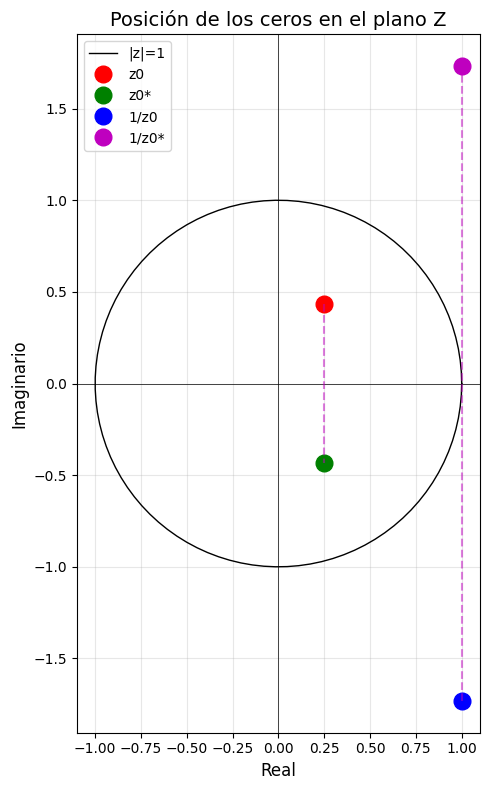


Relación entre los ceros:
- Los ceros vienen en grupos de 4: z0, z0*, 1/z0, 1/z0*
- Esta relación cuadrantal (recíproca y conjugada) garantiza fase lineal
- Si un cero está dentro del UC, su recíproco está fuera (y viceversa)


In [ ]:
# Graficar posición de los ceros en el plano Z
fig, ax = plt.subplots(figsize=(8, 8))

# Círculo unitario
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1, label='|z|=1')

# Ejes
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# Ceros
zeros = [z0, z0_conj, z0_inv, z0_inv_conj]
colors = ['r', 'g', 'b', 'm']
labels = ['z0', 'z0*', '1/z0', '1/z0*']

for z, c, l in zip(zeros, colors, labels):
    ax.plot(np.real(z), np.imag(z), 'o'+c, markersize=12, label=l)

# Líneas de conexión para mostrar relaciones
# Conectar z0 con z0*
ax.plot([np.real(z0), np.real(z0_conj)], [np.imag(z0), np.imag(z0_conj)], 
        '--'+c, alpha=0.5)
# Conectar 1/z0 con 1/z0*
ax.plot([np.real(z0_inv), np.real(z0_inv_conj)], 
        [np.imag(z0_inv), np.imag(z0_inv_conj)], '--'+c, alpha=0.5)

ax.set_xlabel('Real', fontsize=12)
ax.set_ylabel('Imaginario', fontsize=12)
ax.set_title('Posición de los ceros en el plano Z', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('prob7_ceros_planoZ.png', dpi=150)
plt.show()

print("\nRelación entre los ceros:")
print("- Los ceros vienen en grupos de 4: z0, z0*, 1/z0, 1/z0*")
print("- Esta relación cuadrantal (recíproca y conjugada) garantiza fase lineal")
print("- Si un cero está dentro del UC, su recíproco está fuera (y viceversa)")

In [32]:
# Para un sistema FIR con 4 ceros, necesitamos 4 coeficientes
# Más el cero en z=0 (mencionado en el problema) que ya está
# N = 5 significa que hay 5 coeficientes (incluyendo el polo en z=0)

# Los ceros están en: z0, z0*, 1/z0, 1/z0*
# Más el cero en z=0 (que cuenta para la longitud)

# H(z) = (z - z0)(z - z0*)(z - 1/z0)(z - 1/z0*)
#       = z * (z^2 - 2*Re(z0)*z + |z0|^2) * (z^2 - 2*Re(1/z0)*z + |1/z0|^2)

# Calculamos los coeficientes
from numpy.polynomial import polynomial as P

# Factores lineales
# (z - z0)
poly_z0 = [1, -z0]
# (z - z0*)
poly_z0_conj = [1, -z0_conj]
# (z - 1/z0)
poly_z0_inv = [1, -z0_inv]
# (z - 1/z0*)
poly_z0_inv_conj = [1, -z0_inv_conj]

# Multiplicar (z - z0)(z - z0*) = z^2 - 2*Re(z0)*z + |z0|^2
poly1 = np.convolve(poly_z0, poly_z0_conj)
print(f"(z - z0)(z - z0*) = {poly1}")

# Multiplicar (z - 1/z0)(z - 1/z0*)
poly2 = np.convolve(poly_z0_inv, poly_z0_inv_conj)
print(f"(z - 1/z0)(z - 1/z0*) = {poly2}")

# H(z) = poly1 * poly2 (degree 4 polynomial, N=5)
poly_full = np.convolve(poly1, poly2)  # degree 4 → 5 coeffs
print(f"\nH(z) = {poly_full}")

# Extraer coeficientes (deben ser reales)
h_coeffs = np.real(poly_full)
print(f"\nCoeficientes reales: {h_coeffs}")
print(f"\nh[n] = {h_coeffs}")

(z - z0)(z - z0*) = [ 1.  +0.j -0.5 +0.j  0.25+0.j]
(z - 1/z0)(z - 1/z0*) = [ 1.+0.j -2.+0.j  4.+0.j]

H(z) = [ 1.  +0.j -2.5 +0.j  5.25+0.j -2.5 +0.j  1.  +0.j]

Coeficientes reales: [ 1.   -2.5   5.25 -2.5   1.  ]

h[n] = [ 1.   -2.5   5.25 -2.5   1.  ]


In [33]:
# Verificar que los coeficientes son reales
print("Coeficientes (verificación):")
for i, c in enumerate(h_coeffs):
    print(f"  h[{i}] = {c:.6f}")

# Verificar simetría
h = h_coeffs
is_symmetric = np.allclose(h, h[::-1])
is_antisymmetric = np.allclose(h, -h[::-1])

print(f"\n¿Simetría par? {is_symmetric}")
print(f"¿Simetría impar? {is_antisymmetric}")

# Determinar tipo
N = len(h)
if is_symmetric and N % 2 == 1:
    tipo = "Tipo I (N impar, simetría par)"
elif is_symmetric and N % 2 == 0:
    tipo = "Tipo II (N par, simetría par)"
elif is_antisymmetric and N % 2 == 1:
    tipo = "Tipo III (N impar, simetría impar)"
elif is_antisymmetric and N % 2 == 0:
    tipo = "Tipo IV (N par, simetría impar)"
else:
    tipo = "No es FIR de fase lineal estándar"

print(f"Tipo de filtro: {tipo}")

Coeficientes (verificación):
  h[0] = 1.000000
  h[1] = -2.500000
  h[2] = 5.250000
  h[3] = -2.500000
  h[4] = 1.000000

¿Simetría par? True
¿Simetría impar? False
Tipo de filtro: Tipo I (N impar, simetría par)


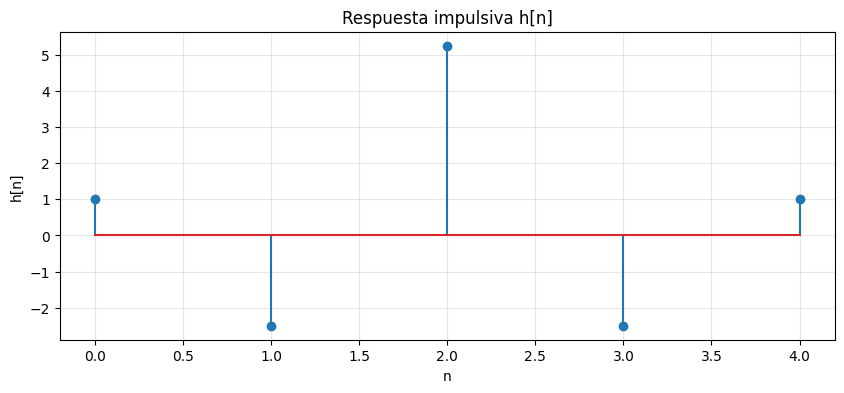

In [ ]:
# Graficar la respuesta al impulso
plt.figure(figsize=(10, 4))
plt.stem(range(N), h)
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('Respuesta impulsiva h[n]')
plt.grid(True, alpha=0.3)
plt.savefig('prob7_h_n.png', dpi=150)
plt.show()

### Resumen Problema 7

**Parte a) Ceros del sistema:**

Para un filtro FIR de fase lineal generalizada con coeficientes reales, los ceros vienen en grupos de 4:
- z₀ = 0.5e^(jπ/3) (dado)
- z₀* = 0.5e^(-jπ/3) (conjugado)
- 1/z₀ = 2e^(-jπ/3) (recíproco)
- 1/z₀* = 2e^(jπ/3) (recíproco conjugado)

**Relación:** Los ceros están en posiciones conjugadas y recíprocas, lo que garantiza fase lineal.

**Parte b) Respuesta impulsiva h[n]:**

La respuesta impulsiva calculada es:
h[n] = \{1, -2.5, 5.25, -2.5, 1\}

**Tipo de filtro:** FIR Tipo I (N=5, simetría par, fase lineal generalizada)
